# 1단계: 데이터 수집 및 전처리

AIHub 속성기반 감정분석 데이터(라벨링데이터 json 50개 zip)를 파싱해서 리뷰/속성 단위 데이터프레임을 만들고, EDA 근거를 바탕으로 정제한 뒤 `data/processed/`에 저장한다.

전체 근거와 결과 해석은 [`results/reports/01_전처리_EDA_보고서.md`](../results/reports/01_전처리_EDA_보고서.md) 참고.

In [1]:
import zipfile
import json
import os
import glob
import re
import time

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 폰트
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)

RAW_BASE = "../data/raw/147.속성기반 감정분석 데이터/01-1.정식개방데이터"
PROCESSED_DIR = "../data/processed"
FIG_DIR = "../results/figures"

## 1. 라벨링데이터 zip 50개 파싱

라벨링데이터(json)에 원문+속성+감성 라벨이 다 있어서 원천데이터(xlsx)는 쓰지 않는다.

**주의**: 원본 `Index`는 도메인을 넘어가면 전역 유일하지 않다(18,405건 중복 확인됨. 예: `Index=100`이 패션/가전에 동시 존재). 그대로 조인 키로 쓰면 다른 리뷰에 엉뚱한 속성 라벨이 붙는 사고가 나므로, `split + zip파일명 + Index`를 합친 `review_id`를 새로 발급해서 쓴다.

In [2]:
def find_label_zips():
    zips = []
    for split in ["Training", "Validation"]:
        pattern = os.path.join(RAW_BASE, split, "02.라벨링데이터", "*.zip")
        for zp in glob.glob(pattern):
            zips.append((split, zp))
    return zips


def load_zip(split, zip_path):
    review_rows, aspect_rows = [], []
    zip_name = os.path.basename(zip_path)
    with zipfile.ZipFile(zip_path) as z:
        json_infos = [i for i in z.infolist() if i.filename.lower().endswith(".json")]
        for info in json_infos:
            with z.open(info) as f:
                try:
                    records = json.load(f)
                except Exception as e:
                    print(f"  [WARN] JSON 파싱 실패: {zip_name} / {info.filename} -> {e}")
                    continue
            if isinstance(records, dict):
                records = [records]
            for rec in records:
                idx = rec.get("Index")
                domain = rec.get("Domain")
                aspects = rec.get("Aspects", [])
                review_id = f"{split}|{zip_name}|{idx}"
                review_rows.append({
                    "review_id": review_id,
                    "Index": idx,
                    "RawText": rec.get("RawText"),
                    "Source": rec.get("Source"),
                    "Domain": domain,
                    "MainCategory": rec.get("MainCategory"),
                    "ProductName": rec.get("ProductName"),
                    "Syllable": rec.get("Syllable"),
                    "Word": rec.get("Word"),
                    "GeneralPolarity": rec.get("GeneralPolarity"),
                    "NumAspects": len(aspects),
                    "split": split,
                    "zip_source": zip_name,
                })
                for asp in aspects:
                    aspect_rows.append({
                        "review_id": review_id,
                        "Index": idx,
                        "Domain": domain,
                        "Aspect": asp.get("Aspect"),
                        "SentimentText": asp.get("SentimentText"),
                        "SentimentWord": asp.get("SentimentWord"),
                        "SentimentPolarity": asp.get("SentimentPolarity"),
                        "split": split,
                        "zip_source": zip_name,
                    })
    return review_rows, aspect_rows


t0 = time.time()
zips = find_label_zips()
print(f"라벨링데이터 zip 총 {len(zips)}개 발견")

all_review_rows, all_aspect_rows = [], []
for split, zp in zips:
    rr, ar = load_zip(split, zp)
    all_review_rows.extend(rr)
    all_aspect_rows.extend(ar)

df_reviews = pd.DataFrame(all_review_rows)
df_aspects = pd.DataFrame(all_aspect_rows)

print(f"리뷰 {df_reviews.shape}, 속성 {df_aspects.shape}, 소요 {time.time()-t0:.1f}초")
df_reviews.head(3)

라벨링데이터 zip 총 50개 발견


리뷰 (225285, 13), 속성 (715366, 9), 소요 4.5초


,review_id,Index,RawText,Source,Domain,MainCategory,ProductName,Syllable,Word,GeneralPolarity,NumAspects,split,zip_source
0,Training|TL_SNS_01.패션.zip|1024338,1024338,안녕하세요 이웃님들 반갑습니다. 요즘 날씨가 많이 쌀쌀해졌죠? 요즘 계절에 입으면 ...,SNS,패션,여성의류,OO 경량 다운 자켓,513,121,1,10,Training,TL_SNS_01.패션.zip
1,Training|TL_SNS_01.패션.zip|1024477,1024477,드디어 겨울이 찾아왔네요. 이제부터 슬슬 겨울 패딩 장만하셔야지요? 패딩 소개해 드...,SNS,패션,여성의류,OO 아** 구스코트,464,105,1,6,Training,TL_SNS_01.패션.zip
2,Training|TL_SNS_01.패션.zip|1025044,1025044,오늘도 정말 춥네요... 롱패딩 찾고 계신 분을 위한 후기 공유합니다. 키 158...,SNS,패션,여성의류,OO 아** 구스코트,314,78,1,6,Training,TL_SNS_01.패션.zip


## 2. 정제 전 EDA

수량, 결측, 중복, 텍스트 길이, 감성 분포, 속성 빈도, 특수문자 패턴을 확인한다. 여기서 나온 수치가 3번(정제 로직)의 근거가 된다.

In [3]:
print("결측치:\n", df_reviews.isnull().sum())
print("\n도메인 분포:\n", df_reviews["Domain"].value_counts())

# Index가 도메인 간 전역 유일하지 않음을 재확인
print("\n원본 Index 전역 중복 건수:", df_reviews["Index"].duplicated().sum())

# 완전 중복은 (RawText, Domain) 조합 기준으로 판단
# (RawText 단독 기준으로 잡으면 도메인 간 정상적인 교차 게재까지 중복으로 오판함 -> 아래 셀에서 검증)
dup_domain = df_reviews.duplicated(subset=["RawText", "Domain"]).sum()
dup_text_only = df_reviews.duplicated(subset=["RawText"]).sum()
print(f"\n(RawText, Domain) 기준 중복: {dup_domain}건")
print(f"RawText 단독 기준 중복: {dup_text_only}건 (도메인 교차 게재 포함, 과대추정)")

결측치:
 review_id              0
Index                  0
RawText                0
Source                 0
Domain                 0
MainCategory           0
ProductName           16
Syllable               0
Word                   0
GeneralPolarity    16984
NumAspects             0
split                  0
zip_source             0
dtype: int64

도메인 분포:
 Domain
가전      45356
IT기기    45150
화장품     45050
생활      44868
패션      44861
Name: count, dtype: int64

원본 Index 전역 중복 건수: 18405



(RawText, Domain) 기준 중복: 0건
RawText 단독 기준 중복: 33건 (도메인 교차 게재 포함, 과대추정)


In [4]:
# 텍스트 길이 분포
df_reviews["char_len"] = df_reviews["RawText"].str.len()
print(df_reviews["char_len"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

# 최단 리뷰가 쓰레기 데이터가 아닌지 직접 확인 -> 완결된 문장으로 확인됨 -> 길이 필터링 안 함
print("\n최단 리뷰(<=10자) 샘플:")
print(df_reviews.loc[df_reviews["char_len"] <= 10, "RawText"].head(5).tolist())

count    225285.000000
mean        107.188890
std          99.373651
min           8.000000
1%           24.000000
5%           36.000000
25%          56.000000
50%          74.000000
75%         108.000000
95%         317.000000
99%         498.000000
max        1000.000000
Name: char_len, dtype: float64

최단 리뷰(<=10자) 샘플:
['기모도 약하고 커요', '얇고 통이 커요', '두껍고 무거워요', '따뜻하고 품질좋네요', '핏도예쁘고 따뜻해요']


In [5]:
# 특수문자/노이즈 패턴 검사
url_re = re.compile(r"https?://\S+|www\.\S+")
html_re = re.compile(r"<[^>]+>")
repeat_re = re.compile(r"(.)\1{3,}")
emoji_re = re.compile("[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]")
whitespace_multi_re = re.compile(r"\s{3,}")

n = len(df_reviews)
for name, pat in [("URL", url_re), ("HTML태그", html_re), ("4회+문자반복", repeat_re),
                   ("이모지", emoji_re), ("공백3칸+", whitespace_multi_re)]:
    cnt = df_reviews["RawText"].str.contains(pat, na=False).sum()
    print(f"{name} 포함 리뷰: {cnt}건 ({cnt/n*100:.2f}%)")

print("\nGeneralPolarity 분포:\n", df_reviews["GeneralPolarity"].value_counts())
print("\n속성(Aspect) 빈도 Top 15:\n", df_aspects["Aspect"].value_counts().head(15))

URL 포함 리뷰: 1건 (0.00%)


HTML태그 포함 리뷰: 47건 (0.02%)


C:\Users\user\AppData\Local\Temp\ipykernel_29632\2781091639.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cnt = df_reviews["RawText"].str.contains(pat, na=False).sum()


4회+문자반복 포함 리뷰: 8247건 (3.66%)


이모지 포함 리뷰: 982건 (0.44%)


공백3칸+ 포함 리뷰: 11121건 (4.94%)

GeneralPolarity 분포:
 GeneralPolarity
1     135319
0      42734
-1     30248
Name: count, dtype: int64

속성(Aspect) 빈도 Top 15:
 Aspect
가격             75735
기능             53254
디자인            41875
품질             37535
사이즈            28509
색상             26959
편의성            19795
제품구성           18693
기능/효과          18541
무게             17897
향/냄새           17686
편의성/사용성/활용도    16423
소재             15252
조작성            15204
보습력/수분감        12394
Name: count, dtype: int64


In [6]:
# RawText 단독 기준 "중복"으로 잡힌 건들이 실제로는 뭔지 확인
# -> 전수 조사 결과 전부 도메인 간 교차 게재(같은 도메인 내 중복은 0건)였음
# -> 그래서 정제 시 dedup 키를 RawText 단독이 아니라 (RawText, Domain)으로 잡는다
dup_groups = df_reviews[df_reviews.duplicated(subset=["RawText"], keep=False)].groupby("RawText")
same_domain, cross_domain = 0, 0
for text, g in dup_groups:
    if g["Domain"].nunique() == 1:
        same_domain += 1
    else:
        cross_domain += 1
print(f"중복 텍스트 그룹 {same_domain+cross_domain}개 중 동일도메인 내: {same_domain}개, 도메인 교차: {cross_domain}개")

중복 텍스트 그룹 33개 중 동일도메인 내: 0개, 도메인 교차: 33개


## 3. 정제 로직 적용

EDA 근거를 바탕으로 결정한 정제 규칙 (자세한 근거는 보고서 참고):

1. 중복 제거: `(RawText, Domain)` 조합 기준 (RawText 단독 기준은 도메인 교차 게재를 오삭제함)
2. HTML 태그 / URL 제거
3. 이모지 제거
4. 반복 문자 정규화: `ㅋㅎㅠㅜ!?~.,` **한정** 3회+ → 2회 (전체 문자에 적용하면 `OOOO` 상품명 마스킹까지 훼손됨)
5. 공백류(공백/개행/탭) 연속 → 단일 공백, 양끝 trim
6. 길이 기반 필터링은 하지 않음 (최단 리뷰도 완결된 문장으로 확인됨)
7. `GeneralPolarity` 결측은 행 삭제하지 않고 유지 (결측이어도 `Aspects`는 정상 존재)

In [7]:
df = df_reviews.drop_duplicates(subset=["RawText", "Domain"], keep="first").reset_index(drop=True)
print(f"1차 중복 제거: {len(df_reviews) - len(df)}건 제거 -> {len(df)}건")

repeat_norm_re = re.compile(r"([ㅋㅎㅠㅜ!?~.,])\1{2,}")
whitespace_re = re.compile(r"[ \t\r\n]{2,}")


def clean_text(text: str) -> str:
    if text is None:
        return text
    t = text
    t = html_re.sub(" ", t)
    t = url_re.sub(" ", t)
    t = emoji_re.sub("", t)
    t = repeat_norm_re.sub(r"\1\1", t)
    t = whitespace_re.sub(" ", t)
    return t.strip()


df["RawText_clean"] = df["RawText"].map(clean_text)
df["GeneralPolarity"] = pd.to_numeric(df["GeneralPolarity"], errors="coerce").astype("Int64")
df["Syllable"] = pd.to_numeric(df["Syllable"], errors="coerce").astype("Int64")
df["Word"] = pd.to_numeric(df["Word"], errors="coerce").astype("Int64")
df["char_len_clean"] = df["RawText_clean"].str.len()

print("정제 후 빈 문자열:", (df["char_len_clean"] == 0).sum(), "건")

1차 중복 제거: 0건 제거 -> 225285건


정제 후 빈 문자열: 0 건


## 4. 형태소분석 (Kiwi)

내용어 품사(명사/동사/형용사/부사/어근/외국어/숫자)만 남겨서 조사·어미·구두점을 제거한다. 별도 불용어 사전을 관리할 필요가 없고 품사 기준이라 근거가 명확하다.

**주의**: kiwipiepy는 불규칙활용 용언을 `VA-I`, `VV-R`처럼 하위 태그로 세분화한다. `tag == "VA"` 처럼 완전 일치로 필터링하면 "무겁다/춥다"류 ㅂ불규칙 형용사가 통째로 누락된다 (실제로 이 버그로 "두껍고 무거워요"가 내용어 0개가 되는 걸 발견함). 반드시 `tag.startswith(...)`로 접두어 매칭해야 한다.

In [8]:
kiwi = Kiwi()
CONTENT_TAG_PREFIXES = ("NNG", "NNP", "VV", "VA", "MAG", "XR", "SL", "SN")


def is_content_tag(tag: str) -> bool:
    return tag.startswith(CONTENT_TAG_PREFIXES)


t0 = time.time()
texts = df["RawText_clean"].tolist()
token_strs, token_counts = [], []
for toks in kiwi.tokenize(texts):
    content = [t.form for t in toks if is_content_tag(t.tag)]
    token_strs.append(" ".join(content))
    token_counts.append(len(content))

df["tokens"] = token_strs
df["token_count"] = token_counts
print(f"형태소분석 완료: {time.time()-t0:.1f}초")
print("내용어 토큰이 0개인 리뷰:", (df["token_count"] == 0).sum(), "건")

형태소분석 완료: 77.6초
내용어 토큰이 0개인 리뷰: 0 건


## 5. 2차 중복 제거 + 리뷰-속성 조인 무결성 검증

공백/반복문자 정규화 과정에서 원래 다르게 보이던 텍스트가 같은 도메인 내에서 새로 동일해지는 경우가 있어 한 번 더 제거한다. 이후 `review_id` 기준으로 리뷰-속성 테이블이 정확히 맞물리는지 검증한다.

In [9]:
n_before_2nd = len(df)
df = df.drop_duplicates(subset=["RawText_clean", "Domain"], keep="first").reset_index(drop=True)
print(f"2차 중복 제거: {n_before_2nd - len(df)}건 -> 최종 {len(df)}건")

valid_ids = set(df["review_id"])
n_asp_before = len(df_aspects)
aspects = df_aspects[df_aspects["review_id"].isin(valid_ids)].reset_index(drop=True)
print(f"속성 테이블: {n_asp_before}건 -> {len(aspects)}건")

# 조인 무결성 검증
orphan_aspects = set(aspects["review_id"]) - set(df["review_id"])
asp_counts = aspects.groupby("review_id").size()
df["_NumAspects_actual"] = df["review_id"].map(asp_counts).fillna(0).astype(int)
mismatch = (df["NumAspects"] != df["_NumAspects_actual"]).sum()
df = df.drop(columns=["_NumAspects_actual"])

print(f"[검증] 속성에는 있는데 리뷰엔 없는 review_id: {len(orphan_aspects)}건 (0이어야 정상)")
print(f"[검증] NumAspects 표기값과 실제 속성 건수 불일치: {mismatch}건 (0이어야 정상)")

2차 중복 제거: 2건 -> 최종 225283건


속성 테이블: 715366건 -> 715358건


[검증] 속성에는 있는데 리뷰엔 없는 review_id: 0건 (0이어야 정상)
[검증] NumAspects 표기값과 실제 속성 건수 불일치: 0건 (0이어야 정상)


## 6. 정제 전후 비교 + 그래프 저장

전체 해석은 [`results/reports/01_전처리_EDA_보고서.md`](../results/reports/01_전처리_EDA_보고서.md) 참고.

HTML태그       정제전     47건 -> 정제후      0건


URL          정제전      1건 -> 정제후      0건


이모지          정제전    982건 -> 정제후      0건


C:\Users\user\AppData\Local\Temp\ipykernel_29632\1146882439.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  before = df_reviews["RawText"].str.contains(pat, na=False).sum()


C:\Users\user\AppData\Local\Temp\ipykernel_29632\1146882439.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  after = df["RawText_clean"].str.contains(pat, na=False).sum()


4회+문자반복      정제전   8247건 -> 정제후   2520건


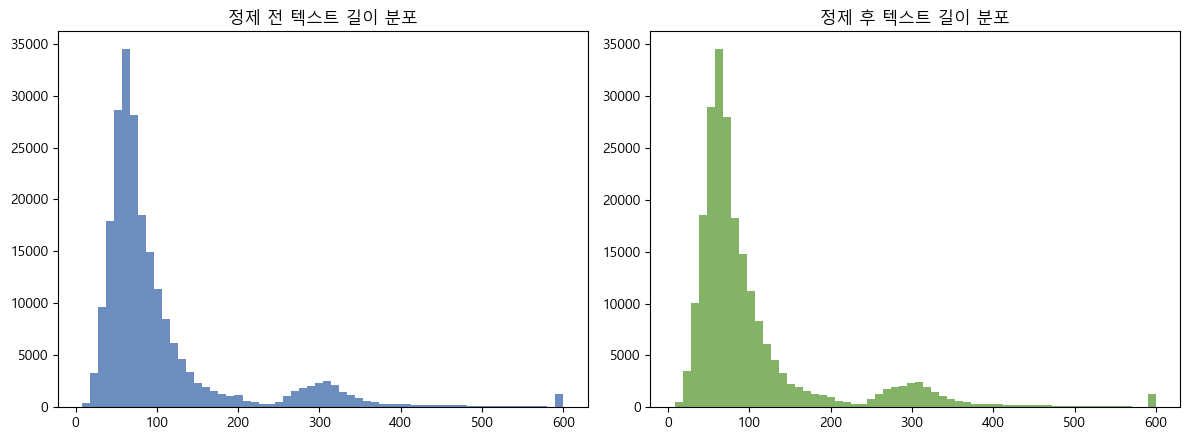

In [10]:
os.makedirs(FIG_DIR, exist_ok=True)

for name, pat in [("HTML태그", html_re), ("URL", url_re), ("이모지", emoji_re), ("4회+문자반복", repeat_re)]:
    before = df_reviews["RawText"].str.contains(pat, na=False).sum()
    after = df["RawText_clean"].str.contains(pat, na=False).sum()
    print(f"{name:<12} 정제전 {before:>6}건 -> 정제후 {after:>6}건")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df_reviews["char_len"].clip(upper=600), bins=60, color="#6C8EBF")
axes[0].set_title("정제 전 텍스트 길이 분포")
axes[1].hist(df["char_len_clean"].clip(upper=600), bins=60, color="#82B366")
axes[1].set_title("정제 후 텍스트 길이 분포")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_text_length_before_after.png"), dpi=150)
plt.show()

## 7. 최종 저장

`data/processed/`는 `.gitignore` 대상이라 Git에는 안 올라간다 (팀원 각자 이 노트북을 실행해서 만들어야 함).

In [11]:
os.makedirs(PROCESSED_DIR, exist_ok=True)
df.to_parquet(os.path.join(PROCESSED_DIR, "reviews.parquet"), index=False)
aspects.to_parquet(os.path.join(PROCESSED_DIR, "aspects.parquet"), index=False)

print("저장 완료")
print("reviews.parquet:", df.shape)
print("aspects.parquet:", aspects.shape)

저장 완료
reviews.parquet: (225283, 18)
aspects.parquet: (715358, 9)
